Loading required library 

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Loading tip.csv dataset from local folder downloaded from kaggle

In [3]:
df = pd.read_csv('tip.csv')

In [4]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Business questions
- Does customer sex affects the tip
- On weekends customer provides more tips
- Which time is perfect to get tip
- More people party gives more tip than solo customer
- Relation between total_bill and tip, higher the bill -- higher the tip?
- Relation between Total bill with time and day  

Observations-
- 244 rows and 7 columns
- no null values present in the dataset
- All the data types are correct
- 3 numerical columns
- 4 categorical columns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


Observations-
- Minimum tip is 1 and max is 10
- avg tip is $3 but max is $10 possible outlier
- avg bill is 19 but max is 50 possibly right skewed 
- avg party sizs is 2.57, mostly small groups are there
-

In [6]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Univariate analysis

#### Calculing Skewness
- The value of skew is 1.13 which is positive that shows right skewed distribution

In [7]:
df['total_bill'].skew().round(2)

np.float64(1.13)

#### Plot histogram for total bill for distribution

- Right skewed distribution
- Majority customer paid bill between 10-25

<Axes: xlabel='total_bill', ylabel='Count'>

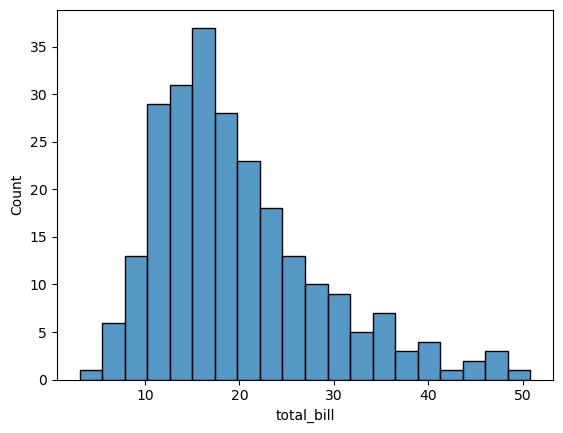

In [8]:
sns.histplot(df, x='total_bill', bins=20)

#### Calculating skewness
- The value of tip skewness is 1.47 which shows more higher right skewness

In [9]:
df['tip'].skew().round(2)

np.float64(1.47)

#### Plot histogram for total bill for distribution
- Most people gives tips between $1-$4 observed

<Axes: xlabel='tip', ylabel='Count'>

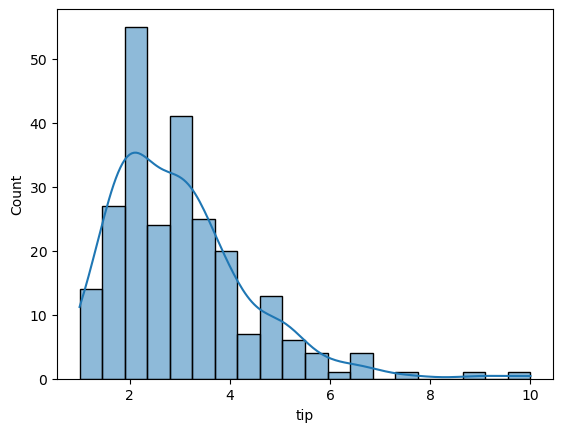

In [10]:
sns.histplot(df, x='tip', bins=20, kde=True)

#### Bivariate analysis 
- Males pays high amount for tip 3.08 than females avg 2.83
- Males gives (count=157) more tip than females (count=87)
- The difference is small — only $0.26. Gender alone is not a strong predictor of tip amount.


In [ ]:
df.groupby('sex')['tip'].mean()

sex
Female    2.833448
Male      3.089618
Name: tip, dtype: float64

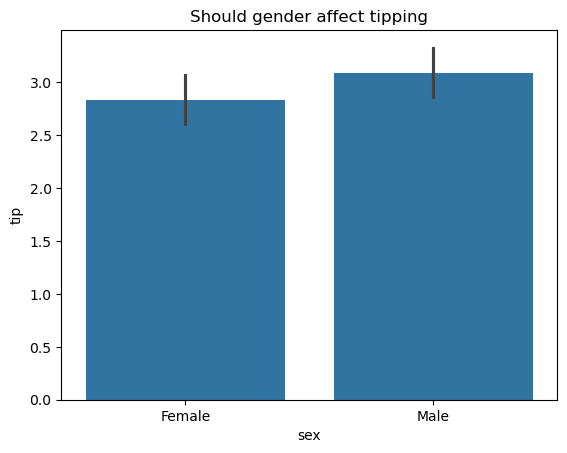

In [12]:
sns.barplot(df, x='sex', y='tip')
plt.title('Should gender affect tipping')
plt.show()

#### Bivariate analysis
- The day on which the highest chance of getting tip are weekends
- | Sun | 87 |
  | Sat | 76 |
- Also on weekends tip amounts are bigger than weekdays-  avg Sunday - ~3.2 and avg Saturday - ~3

In [13]:
df.groupby('day')['tip'].mean().sort_values(ascending=False)

day
Sun     3.255132
Sat     2.993103
Thur    2.771452
Fri     2.734737
Name: tip, dtype: float64

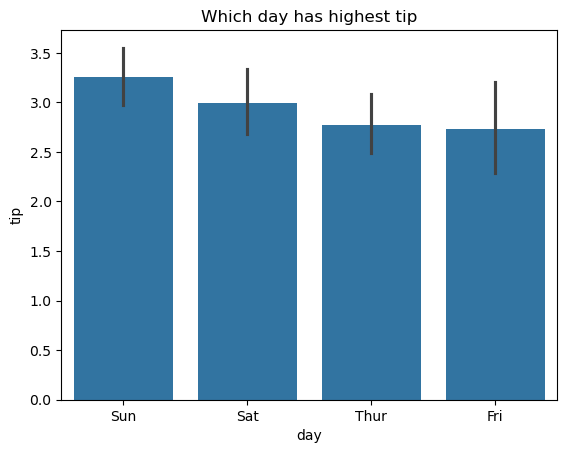

In [14]:
sns.barplot(df, x='day', y='tip')
plt.title('Which day has highest tip')
plt.show()

#### Bivariate analysis
- On Dinner chances of getting tip is higher than lunch and also can get high paying tip of average, dinner- 3.10 and lunch- 2.73

In [15]:
df.groupby('time')['tip'].mean().round(2)

time
Dinner    3.10
Lunch     2.73
Name: tip, dtype: float64

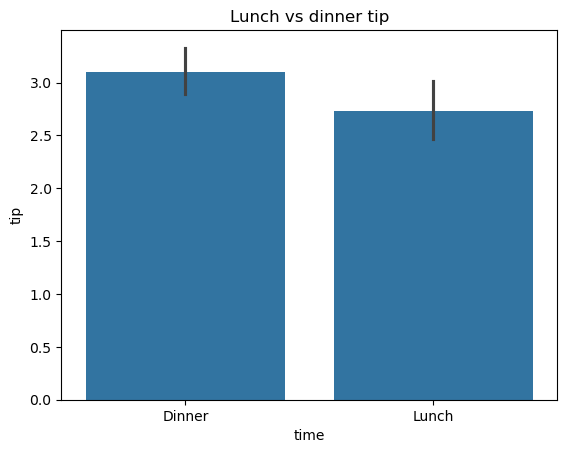

In [16]:
sns.barplot(df, x='time', y='tip')
plt.title('Lunch vs dinner tip')
plt.show()

#### Bivariate analysis
- As we can see majority data points clustered between $10-$25 total bill and $1-$4 tip
- higher tips are provided by only males when having higher total bill and even when there is normal total bill

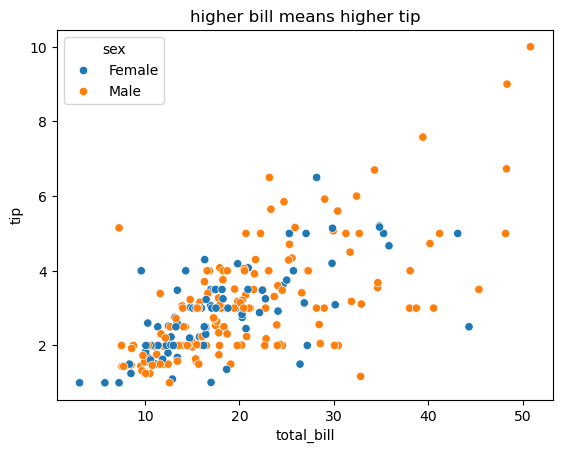

In [17]:
sns.scatterplot(df, x='total_bill', y='tip', hue='sex')
plt.title('higher bill means higher tip')
plt.show()

#### Bivariate analysis
- There is almost no difference means smoker column cannot predict tip, not a strong predictor

In [18]:
df.groupby('smoker')['tip'].mean().round(2)

smoker
No     2.99
Yes    3.01
Name: tip, dtype: float64

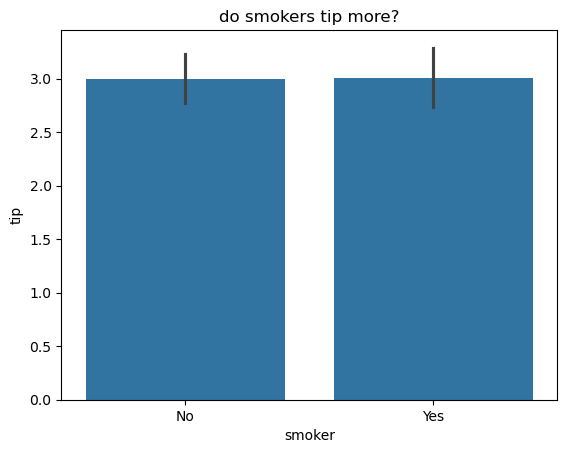

In [19]:
sns.barplot(df, x='smoker', y='tip')
plt.title('do smokers tip more?')
plt.show()

Plot violinplot of tip
- Saturday has the widest tip spread — violin extends to $10 indicating high variability. Thursday has the most consistent distribution — narrow violin concentrated between $2-4. Friday has fewest data points so the violin appears thin.

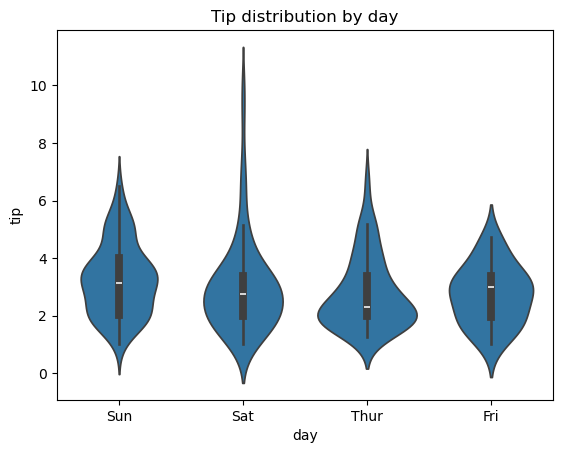

In [20]:
sns.violinplot(data=df, x='day', y='tip')
plt.title('Tip distribution by day')
plt.show()

# Conclusion

`Dataset overview`
- Dataset contains 244 rows and 7 columns
- Its has the data about the tip given by the customer
- There is no missing values in the dataset
- Dataset contains skewness

`Key Insights`
- Males tip slightly more on average ($3.09 vs $2.83) but difference is small
- Sunday has highest average tip ($3.26), Friday lowest ($2.73)
- Dinner service generates higher tips than lunch ($3.10 vs $2.73)
- Total bill and tip are positively correlated — higher bill, higher tip
- Smoker status has almost no effect on tip amount

`Which Ml model should try and why`
- If predicting tip amount — Linear Regression first since tip is a continuous variable and total_bill shows clear linear relationship with tip. If predicting whether tip is above/below average — Logistic Regression or Decision Tree.